# Data Merging Pipeline

In [1]:
import pandas as pd
import numpy as np
import glob
import os

# --- BLOCK 1: CONFIGURATION ---
# Define absolute paths for data source and output destination
# Using raw strings (r'') to handle Windows backslashes correctly

RAW_DATA_PATH = r'C:\Users\sdam1\Desktop\Thesis Master IESEG\RAW Data'
OUTPUT_PATH = r'C:\Users\sdam1\Desktop\Thesis Master IESEG'
OUTPUT_FILE = os.path.join(OUTPUT_PATH, 'Master_Wide_Data.csv')

print(f"Data Source: {RAW_DATA_PATH}")
print(f"Output Destination: {OUTPUT_FILE}")

Data Source: C:\Users\sdam1\Desktop\Thesis Master IESEG\RAW Data
Output Destination: C:\Users\sdam1\Desktop\Thesis Master IESEG\Master_Wide_Data.csv


In [2]:
# --- BLOCK 2: DATA PROCESSING FUNCTION ---

def execute_merge():
    """
    Reads all Excel files from RAW_DATA_PATH, cleans 'n.a.' values,
    and merges them into a single consolidated DataFrame.
    """
    # Find all .xlsx files in the directory
    excel_files = glob.glob(os.path.join(RAW_DATA_PATH, "*.xlsx"))
    
    if not excel_files:
        print("Error: No Excel files found in the specified directory.")
        return None

    all_dataframes = []
    print(f"Starting to process {len(excel_files)} files...")

    for i, file_path in enumerate(excel_files, 1):
        file_name = os.path.basename(file_path)
        
        # Skip temporary Office files (e.g., ~$Data.xlsx)
        if file_name.startswith('~$'):
            continue
            
        try:
            # Read Excel file - Orbis files are usually standard; openpyxl is a reliable engine
            df_temp = pd.read_excel(file_path, engine='openpyxl')

            # CRITICAL STEP: Replace Orbis 'n.a.' with NaN so Python can perform math later
            df_temp.replace('n.a.', np.nan, inplace=True)

            # CLEANUP: Remove rows where the company name or BvD ID is missing (headers/footers)
            # Identifying columns by typical Orbis names
            name_col = 'Company name Latin alphabet'
            bvd_col = 'BvD ID number'
            
            if name_col in df_temp.columns:
                df_temp = df_temp.dropna(subset=[name_col])
            
            # Additional cleanup for completely empty rows/columns
            df_temp.dropna(how='all', axis=0, inplace=True)

            all_dataframes.append(df_temp)
            print(f"[{i}/{len(excel_files)}] Processed: {file_name} | Rows: {len(df_temp)}")

        except Exception as e:
            print(f"FAILED to process {file_name}: {str(e)}")

    # Combine all dataframes into one
    if all_dataframes:
        master_df = pd.concat(all_dataframes, ignore_index=True)
        
        # Final integrity check: Drop duplicates based on BvD ID number
        if 'BvD ID number' in master_df.columns:
            master_df.drop_duplicates(subset=['BvD ID number'], inplace=True)
        else:
            master_df.drop_duplicates(inplace=True)
            
        return master_df
    return None

In [3]:
# --- BLOCK 3: EXECUTION ---

final_data = execute_merge()

if final_data is not None:
    # Saving to CSV in the Master folder
    final_data.to_csv(OUTPUT_FILE, index=False)
    print("-" * 30)
    print(f"✅ SUCCESS!")
    print(f"Total Companies Merged: {len(final_data)}")
    print(f"File Saved at: {OUTPUT_FILE}")
else:
    print("❌ Merge failed. Please check the paths or file formats.")

Starting to process 36 files...


C:\Users\sdam1\AppData\Local\Temp\ipykernel_20752\1768852395.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.replace('n.a.', np.nan, inplace=True)


[1/36] Processed: data_105001_112500.xlsx | Rows: 7500


C:\Users\sdam1\AppData\Local\Temp\ipykernel_20752\1768852395.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.replace('n.a.', np.nan, inplace=True)


[2/36] Processed: data_112501_120000.xlsx | Rows: 7500


...

[34/36] Processed: data_82501_90000.xlsx | Rows: 7500


C:\Users\sdam1\AppData\Local\Temp\ipykernel_20752\1768852395.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.replace('n.a.', np.nan, inplace=True)


[35/36] Processed: data_90001_97500.xlsx | Rows: 7500


C:\Users\sdam1\AppData\Local\Temp\ipykernel_20752\1768852395.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_temp.replace('n.a.', np.nan, inplace=True)


[36/36] Processed: data_97501_105000.xlsx | Rows: 7500
------------------------------
✅ SUCCESS!
Total Companies Merged: 268683
File Saved at: C:\Users\sdam1\Desktop\Thesis Master IESEG\Master_Wide_Data.csv


In [4]:
# --- BLOCK 4: DATA INSPECTION AND SUMMARY REPORT ---

import pandas as pd

def generate_data_report(file_path):
    """
    Reads the merged CSV and prints structural information 
    to ensure the merge was successful and data types are correct.
    """
    try:
        # Load the master file
        df_master = pd.read_csv(file_path)
        
        print("--- DATASET OVERVIEW ---")
        print(f"Total Rows: {len(df_master)}")
        print(f"Total Columns: {len(df_master.columns)}")
        
        print("\n--- COLUMN NAMES AND DATA TYPES ---")
        # Displaying first 20 columns to check the structure
        print(df_master.info(verbose=True, show_counts=True))
        
        print("\n--- DATA SAMPLE (FIRST 5 ROWS) ---")
        # Checking the first few rows to verify the 'n.a.' conversion
        print(df_master.head())
        
        print("\n--- MISSING VALUES SUMMARY ---")
        # Check percentage of missing values per year group (example for Total Assets)
        asset_cols = [col for col in df_master.columns if 'Total assets' in col]
        missing_summary = df_master[asset_cols].isnull().mean() * 100
        print("Percentage of missing values for Total Assets columns:")
        print(missing_summary)

    except Exception as e:
        print(f"Error during inspection: {e}")

# Run the report
generate_data_report(OUTPUT_FILE)

--- DATASET OVERVIEW ---
Total Rows: 268683
Total Columns: 132

--- COLUMN NAMES AND DATA TYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268683 entries, 0 to 268682
Data columns (total 132 columns):
 #    Column                                              Non-Null Count   Dtype  
---   ------                                              --------------   -----  
 0    Unnamed: 0                                          268683 non-null  float64
 1    Company name Latin alphabet                         268683 non-null  object 
 2    Inactive                                            268683 non-null  object 
 3    Quoted                                              268683 non-null  object 
 4    Branch                                              268683 non-null  object 
 5    OwnData                                             268683 non-null  object 
 6    Woco                                                268683 non-null  object 
 7    Country ISO code                   

# FILTERING & RESHAPING

Block code này sẽ thực hiện 3 nhiệm vụ:
- Lọc ngành: Chỉ giữ lại Construction (NACE 41-43), Wholesale (46), Retail (47).
- Lọc quy mô SME: Loại bỏ Large Caps (Tài sản > 43M EUR).
- Reshape (Wide to Long): Xoay dữ liệu để mỗi năm là một dòng.

In [5]:
import pandas as pd
import numpy as np
import os

# --- BLOCK 5: DATA FILTERING AND RESHAPING (WIDE TO LONG) ---
# Purpose: Filter for specific industries and SME sizes, then pivot the table for time-series analysis.

def process_milestone_2(input_file, output_file):
    print("Loading master data... This may take a minute due to file size.")
    df = pd.read_csv(input_file)
    
    # 1. CLEAN COLUMN NAMES
    # Remove newlines '\n' and extra spaces from Orbis headers for easier coding
    df.columns = [col.replace('\n', ' ').strip() for col in df.columns]
    
    # 2. INDUSTRY FILTERING (NACE Rev. 2)
    # Construction: 41, 42, 43 | Wholesale: 46 | Retail: 47
    # We take the first 2 digits of the NACE code
    df['NACE_2digit'] = df['NACE Rev. 2, core code (4 digits)'].fillna(0) // 100
    target_sectors = [41, 42, 43, 46, 47]
    df = df[df['NACE_2digit'].isin(target_sectors)]
    print(f"Filter 1: Industry applied. Remaining companies: {df['BvD ID number'].nunique()}")

    # 3. SME SIZE FILTERING (Standard EU Definition)
    # Filter out Large Caps (Total Assets > 43M EUR in the latest available year 2023)
    # Note: We use 2023 as 2024 data is still coming in.
    df = df[df['Total assets EUR 2023'] <= 43000000]
    print(f"Filter 2: SME Size applied (Assets <= 43M). Remaining: {df['BvD ID number'].nunique()}")

    # 4. PREPARE FOR MELTING
    # Define columns that stay constant (Identifiers)
    id_vars = [
        'BvD ID number', 'Company name Latin alphabet', 'NACE Rev. 2, core code (4 digits)',
        'NACE_2digit', 'Inactive', 'Status date', 'Country ISO code'
    ]
    
    # Define financial metrics to be pivoted
    metrics_mapping = {
        'Total assets EUR': 'Total_Assets',
        'Current assets EUR': 'Current_Assets',
        'Operating revenue (Turnover) EUR': 'Revenue',
        'Working capital EUR': 'Working_Capital',
        'Shareholders funds EUR': 'Equity',
        'Long term debt EUR': 'Long_Term_Debt',
        'Operating profit (loss) [EBIT] EUR': 'EBIT',
        'Profit (loss) for the period [Net income] EUR': 'Net_Income',
        'Financial expenses EUR': 'Financial_Expenses',
        'Current liabilities EUR': 'Current_Liabilities'
    }

    # Helper function to melt one metric at a time to save memory
    melted_parts = []
    for orbis_prefix, clean_name in metrics_mapping.items():
        # Find all columns for this metric (e.g., all years of Total Assets)
        value_vars = [c for c in df.columns if orbis_prefix in c and ".1" not in c and ".2" not in c]
        
        melted = pd.melt(df, id_vars=['BvD ID number'], value_vars=value_vars, 
                         var_name='Year', value_name=clean_name)
        
        # Extract numeric year from string (e.g., 'Total assets EUR 2023' -> 2023)
        melted['Year'] = melted['Year'].str.extract('(\d{4})').astype(int)
        melted_parts.append(melted.set_index(['BvD ID number', 'Year']))

    # Combine all melted metrics into one Long DataFrame
    df_long = pd.concat(melted_parts, axis=1).reset_index()
    
    # 5. MERGE BACK CONSTANT INFO
    # Bring back company name, industry, status, etc.
    df_final = df_long.merge(df[id_vars], on='BvD ID number', how='left')
    
    # 6. TARGET VARIABLE LOGIC
    # Label as bankrupt (1) if Inactive is Yes AND the current row Year matches the Status date Year
    df_final['Status_Year'] = pd.to_datetime(df_final['Status date'], errors='coerce').dt.year
    df_final['Target'] = 0
    df_final.loc[(df_final['Inactive'] == 'Yes') & (df_final['Year'] == df_final['Status_Year']), 'Target'] = 1
    
    # Save the cleaned long format data
    df_final.to_csv(output_file, index=False)
    print(f"\n✅ SUCCESS: Milestone 2 Complete.")
    print(f"Final Long Format Data: {len(df_final)} rows.")
    print(f"Saved to: {output_file}")
    
    return df_final

# Define paths (Using your current configuration)
MASTER_FILE = os.path.join(OUTPUT_PATH, 'Master_Wide_Data.csv')
LONG_DATA_FILE = os.path.join(OUTPUT_PATH, 'Master_Long_Data.csv')
df_long = process_milestone_2(MASTER_FILE, LONG_DATA_FILE)

Loading master data... This may take a minute due to file size.


<>:61: SyntaxWarning: invalid escape sequence '\d'
<>:61: SyntaxWarning: invalid escape sequence '\d'
C:\Users\sdam1\AppData\Local\Temp\ipykernel_20752\3333394390.py:61: SyntaxWarning: invalid escape sequence '\d'
  melted['Year'] = melted['Year'].str.extract('(\d{4})').astype(int)


Filter 1: Industry applied. Remaining companies: 240300
Filter 2: SME Size applied (Assets <= 43M). Remaining: 181002

✅ SUCCESS: Milestone 2 Complete.
Final Long Format Data: 1810020 rows.
Saved to: C:\Users\sdam1\Desktop\Thesis Master IESEG\Master_Long_Data.csv


# Feature Engineering

In [6]:
import pandas as pd
import numpy as np

# --- BLOCK 6: FINANCIAL RATIOS AND MATURITY SCORE ---
# Purpose: Define the core financial health of each SME and its data longevity.

def calculate_ratios_and_maturity(input_file, output_file):
    print("Loading long format data...")
    df = pd.read_csv(input_file)
    
    # 1. CALCULATE CORE FINANCIAL RATIOS
    # Profitability: Return on Assets
    df['ROA'] = df['Net_Income'] / df['Total_Assets']
    
    # Liquidity: Current Ratio
    df['Current_Ratio'] = df['Current_Assets'] / df['Current_Liabilities']
    
    # Solvency: Debt Ratio (Using sum of current and long term debt as proxy for total liabilities)
    df['Total_Debt'] = df['Current_Liabilities'].fillna(0) + df['Long_Term_Debt'].fillna(0)
    df['Debt_Ratio'] = df['Total_Debt'] / df['Total_Assets']
    
    # Efficiency: Operating Margin
    df['Op_Margin'] = df['EBIT'] / df['Revenue']
    
    # Financial Pressure: Interest Burden
    df['Interest_Burden'] = df['Financial_Expenses'] / df['Revenue']

    # 2. CALCULATE MATURITY SCORE (Data Tenure)
    # Find the first year each company appears with valid Total Assets
    first_year = df[df['Total_Assets'].notnull()].groupby('BvD ID number')['Year'].transform('min')
    df['Maturity_Score'] = df['Year'] - first_year
    
    # 3. CLEANING RATIOS (Handling Infinite/Extreme Outliers from division by zero)
    # Replace inf with NaN and then cap extreme values at 1st and 99th percentiles
    cols_to_cap = ['ROA', 'Current_Ratio', 'Debt_Ratio', 'Op_Margin', 'Interest_Burden']
    for col in cols_to_cap:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        upper_limit = df[col].quantile(0.99)
        lower_limit = df[col].quantile(0.01)
        df[col] = df[col].clip(lower_limit, upper_limit)

    print(f"Ratios and Maturity Score calculated. Data points: {len(df)}")
    return df

df_ratios = calculate_ratios_and_maturity(LONG_DATA_FILE, "Temporary_Ratios.csv")

Loading long format data...
Ratios and Maturity Score calculated. Data points: 1810020


In [7]:
# --- BLOCK 7: LAGGING, TRENDS, AND MACRO INTEGRATION ---
# Purpose: Create predictive features (T-1) and merge with French Macroeconomic indicators.

def integrate_macro_and_trends(df, macro_file, final_output):
    # 1. SORTING FOR TIME-SERIES CALCULATION
    df = df.sort_values(by=['BvD ID number', 'Year'])

    # 2. CREATE LAGGED FEATURES (T-1)
    # We use data from the previous year to predict the current year's status
    features_to_lag = ['ROA', 'Current_Ratio', 'Debt_Ratio', 'Interest_Burden', 'Total_Assets']
    for feat in features_to_lag:
        df[f'{feat}_Lag1'] = df.groupby('BvD ID number')[feat].shift(1)

    # 3. CREATE TREND FEATURES (Delta T-1 vs T-3)
    # Measures the trajectory of the company
    df['ROA_Trend'] = df.groupby('BvD ID number')['ROA'].diff(2) # Change over 2 years
    df['Revenue_Growth'] = df.groupby('BvD ID number')['Revenue'].pct_change(1)

    # 4. MERGE MACRO DATA
    macro_df = pd.read_csv(macro_file)
    # We use Lagged Macro Data: Interest rate of year T-1 affects the risk of year T
    macro_df_lagged = macro_df.copy()
    macro_df_lagged['Year'] = macro_df_lagged['Year'] + 1 
    
    df_merged = df.merge(macro_df_lagged, on='Year', how='left')

    # 5. CREATE INTERACTION FEATURE (The Thesis "Kill Shot")
    # High Debt * High Interest Rate = Critical Risk
    df_merged['Debt_Interest_Interact'] = df_merged['Debt_Ratio_Lag1'] * df_merged['Macro_Interest_Rate']

    # 6. FINAL CLEANING: Drop rows where we don't have lagged data (e.g., the first year of each company)
    # Also drop the first year of our study (2015) as it has no Lag1
    df_merged = df_merged[df_merged['Year'] > 2015]
    
    # Save the Final Analytic File
    df_merged.to_csv(final_output, index=False)
    print(f"✅ SUCCESS: Analytic dataset ready for ML.")
    print(f"Final features: {df_merged.columns.tolist()}")
    return df_merged

MACRO_FILE = r'C:\Users\sdam1\Desktop\Thesis Master IESEG\FRANCE_MACRO_FULL_2015_2024.csv'
FINAL_ML_FILE = os.path.join(OUTPUT_PATH, 'Final_Analytic_Data.csv')
df_final = integrate_macro_and_trends(df_ratios, MACRO_FILE, FINAL_ML_FILE)

C:\Users\sdam1\AppData\Local\Temp\ipykernel_20752\2634492529.py:17: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Revenue_Growth'] = df.groupby('BvD ID number')['Revenue'].pct_change(1)


✅ SUCCESS: Analytic dataset ready for ML.
Final features: ['BvD ID number', 'Year', 'Total_Assets', 'Current_Assets', 'Revenue', 'Working_Capital', 'Equity', 'Long_Term_Debt', 'EBIT', 'Net_Income', 'Financial_Expenses', 'Current_Liabilities', 'Company name Latin alphabet', 'NACE Rev. 2, core code (4 digits)', 'NACE_2digit', 'Inactive', 'Status date', 'Country ISO code', 'Status_Year', 'Target', 'ROA', 'Current_Ratio', 'Total_Debt', 'Debt_Ratio', 'Op_Margin', 'Interest_Burden', 'Maturity_Score', 'ROA_Lag1', 'Current_Ratio_Lag1', 'Debt_Ratio_Lag1', 'Interest_Burden_Lag1', 'Total_Assets_Lag1', 'ROA_Trend', 'Revenue_Growth', 'Macro_GDP_Growth', 'Macro_Inflation', 'Macro_Interest_Rate', 'Macro_Unemployment', 'Debt_Interest_Interact']


# ML Models

In [8]:
# --- BLOCK 8: ADVANCED DATA PREPARATION ---
# Purpose: Prepare features, handle remaining NaNs, and perform Temporal Splitting.
# Train Period: 2016-2022 | Test Period (Out-of-Time): 2023-2024

from sklearn.preprocessing import StandardScaler
import numpy as np

def prepare_final_ml_data(df):
    # 1. SELECT FINAL FEATURES
    features = [
        'ROA_Lag1', 'Current_Ratio_Lag1', 'Debt_Ratio_Lag1', 'Interest_Burden_Lag1', 
        'Total_Assets_Lag1', 'ROA_Trend', 'Revenue_Growth', 'Maturity_Score', 
        'Macro_GDP_Growth', 'Macro_Inflation', 'Macro_Interest_Rate', 
        'Macro_Unemployment', 'Debt_Interest_Interact'
    ]
    
    # 2. TEMPORAL SPLIT
    # We train on the past (up to 2022) and test on the "future" (2023-2024)
    train_mask = (df['Year'] <= 2022)
    test_mask = (df['Year'] >= 2023) & (df['Year'] <= 2024)
    
    X_train_raw = df.loc[train_mask, features]
    y_train = df.loc[train_mask, 'Target']
    X_test_raw = df.loc[test_mask, features]
    y_test = df.loc[test_mask, 'Target']
    
    # 3. HANDLE MISSING & INFINITE VALUES
    # Replacing inf with NaN and then filling with median
    X_train_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_test_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    impute_values = X_train_raw.median()
    X_train_filled = X_train_raw.fillna(impute_values)
    X_test_filled = X_test_raw.fillna(impute_values)
    
    # 4. STANDARDIZATION
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_filled)
    X_test_scaled = scaler.transform(X_test_filled)
    
    print(f"Preparation Complete:")
    print(f"Training set: {X_train_scaled.shape[0]} rows (2016-2022)")
    print(f"Testing set (OOT): {X_test_scaled.shape[0]} rows (2023-2024)")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, features

X_train, X_test, y_train, y_test, feature_names = prepare_final_ml_data(df_final)

Preparation Complete:
Training set: 1267014 rows (2016-2022)
Testing set (OOT): 362004 rows (2023-2024)


In [9]:
# --- BLOCK 9: STRATEGY 1 - TIME SERIES CROSS-VALIDATION (STABILITY) ---
# Purpose: Test all models using Walk-Forward Validation on the Training Set (2016-2022).
# This measures how consistently the models perform over chronological folds in the past.

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd

# 1. Initialize models with class weight handling for imbalance
# 'ratio' was calculated in your previous steps (Negative/Positive samples)
ratio = (len(y_train) - y_train.sum()) / y_train.sum()

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1),
    "XGBoost": XGBClassifier(scale_pos_weight=ratio, n_estimators=100, learning_rate=0.05, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(scale_pos_weight=ratio, n_estimators=100, learning_rate=0.05, verbosity=-1)
}

# 2. Setup TimeSeriesSplit (5 folds)
tscv = TimeSeriesSplit(n_splits=5)
cv_results = []

print("Running Strategy 1: TimeSeriesSplit on Train set (2016-2022)...")

for name, model in models.items():
    # We use AUC-ROC as the primary metric for bankruptcy prediction
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring='roc_auc')
    cv_results.append({
        "Model": name,
        "CV_AUC_Mean": scores.mean(),
        "CV_AUC_Std": scores.std()
    })
    print(f"  - {name} CV AUC: {scores.mean():.4f}")

df_cv_results = pd.DataFrame(cv_results)

Running Strategy 1: TimeSeriesSplit on Train set (2016-2022)...
  - Logistic Regression CV AUC: 0.6376
  - Random Forest CV AUC: 0.4732
  - XGBoost CV AUC: 0.5328
  - LightGBM CV AUC: 0.4813


In [10]:
# --- BLOCK 10: STRATEGY 2 - OUT-OF-TIME VALIDATION (GENERALIZATION) ---
# Purpose: Train all models on the FULL Training set (2016-2022) 
# and test them on the unseen OOT set (2023-2024).

from sklearn.metrics import roc_auc_score

oot_results = []

print("\nRunning Strategy 2: Out-of-Time Test on 2023-2024...")

for name, model in models.items():
    # Train on the entire 2016-2022 period
    model.fit(X_train, y_train)
    
    # Predict on the 2023-2024 period (the 'future' for the model)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_prob)
    
    oot_results.append({
        "Model": name,
        "OOT_AUC": auc_score
    })
    print(f"  - {name} OOT AUC: {auc_score:.4f}")

df_oot_results = pd.DataFrame(oot_results)


Running Strategy 2: Out-of-Time Test on 2023-2024...
  - Logistic Regression OOT AUC: 0.6037
  - Random Forest OOT AUC: 0.5488
  - XGBoost OOT AUC: 0.6793
  - LightGBM OOT AUC: 0.6113


In [38]:
from sklearn.linear_model import LogisticRegression

# Đảm bảo đã huấn luyện mô hình trước khi tính metrics
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Predict probabilities and classes for OOT (2023-2024)
# Logistic Regression
y_prob_lr = logreg_model.predict_proba(X_test)[:, 1]
y_pred_lr = logreg_model.predict(X_test)

# Baseline XGBoost
y_prob_xgb = champion_model.predict_proba(X_test)[:, 1]
y_pred_xgb = champion_model.predict(X_test)

# Tuned XGBoost
y_prob_tuned = tuned_champion.predict_proba(X_test)[:, 1]
y_pred_tuned = tuned_champion.predict(X_test)

# Calculate metrics
def get_metrics(y_true, y_prob, y_pred):
    return {
        "AUC": roc_auc_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

metrics_lr = get_metrics(y_test, y_prob_lr, y_pred_lr)
metrics_xgb = get_metrics(y_test, y_prob_xgb, y_pred_xgb)
metrics_tuned = get_metrics(y_test, y_prob_tuned, y_pred_tuned)

# Display results
results = pd.DataFrame({
    "Logistic Regression": metrics_lr,
    "Baseline XGBoost": metrics_xgb,
    "Tuned XGBoost": metrics_tuned
}).T

print("--- OOT 2023-2024 Model Metrics ---")
print(results)

c:\ProgramData\anaconda3\envs\py\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- OOT 2023-2024 Model Metrics ---
                     AUC  Precision  Recall  F1-score
Logistic Regression 0.66       0.00    0.00      0.00
Baseline XGBoost    0.68       0.00    0.02      0.00
Tuned XGBoost       0.57       0.01    0.13      0.01


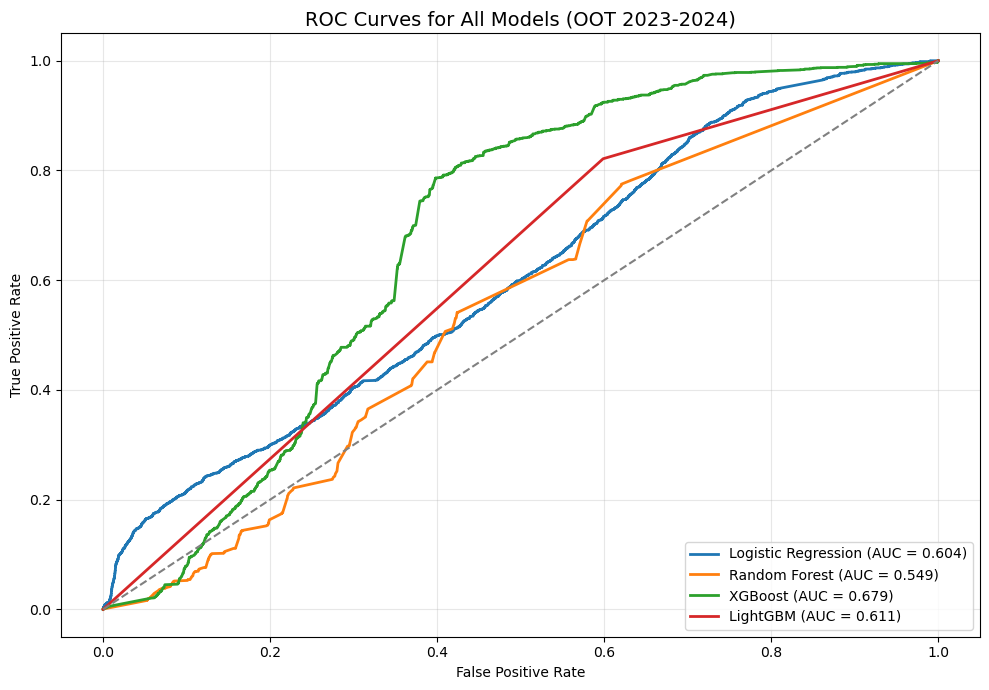

In [12]:
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

# Get OOT predictions for all models
model_preds = {}
model_aucs = {}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    model_preds[name] = (fpr, tpr)
    model_aucs[name] = roc_auc

# Plot all ROC curves
plt.figure(figsize=(10, 7))
for name, (fpr, tpr) in model_preds.items():
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {model_aucs[name]:.3f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curves for All Models (OOT 2023-2024)", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("All_Models_ROC_OOT.png", dpi=300)
plt.show()


--- FINAL LEADERBOARD ---
                 Model  CV_AUC_Mean  CV_AUC_Std   OOT_AUC
2              XGBoost     0.532847    0.051495  0.679323
3             LightGBM     0.481279    0.138170  0.611332
0  Logistic Regression     0.637603    0.058780  0.603711
1        Random Forest     0.473176    0.126179  0.548776

Comparison chart saved as 'Thesis_Model_Comparison.png'


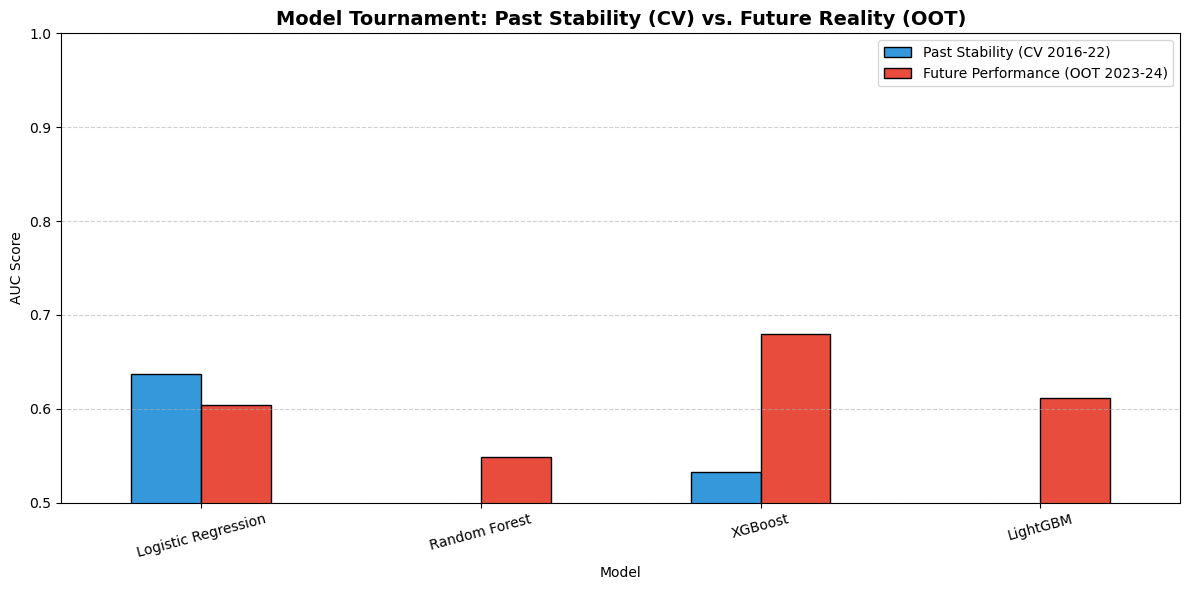

In [13]:
# --- BLOCK 11: FINAL COMPARISON AND VISUALIZATION ---
# Purpose: Combine results from both strategies to identify the overall Champion.

import matplotlib.pyplot as plt

# Merge results from both strategies
comparison_df = df_cv_results.merge(df_oot_results, on="Model")

print("\n--- FINAL LEADERBOARD ---")
print(comparison_df.sort_values(by="OOT_AUC", ascending=False))

# Plotting the comparison
ax = comparison_df.plot(x="Model", y=["CV_AUC_Mean", "OOT_AUC"], kind="bar", 
                        figsize=(12, 6), color=['#3498db', '#e74c3c'], edgecolor='black')

plt.title("Model Tournament: Past Stability (CV) vs. Future Reality (OOT)", fontsize=14, fontweight='bold')
plt.ylabel("AUC Score")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.legend(["Past Stability (CV 2016-22)", "Future Performance (OOT 2023-24)"])
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Thesis_Model_Comparison.png")
print("\nComparison chart saved as 'Thesis_Model_Comparison.png'")


🏆 The Final Champion is: XGBoost
✅ SHAP Analysis saved as 'Champion_SHAP_Analysis.png'


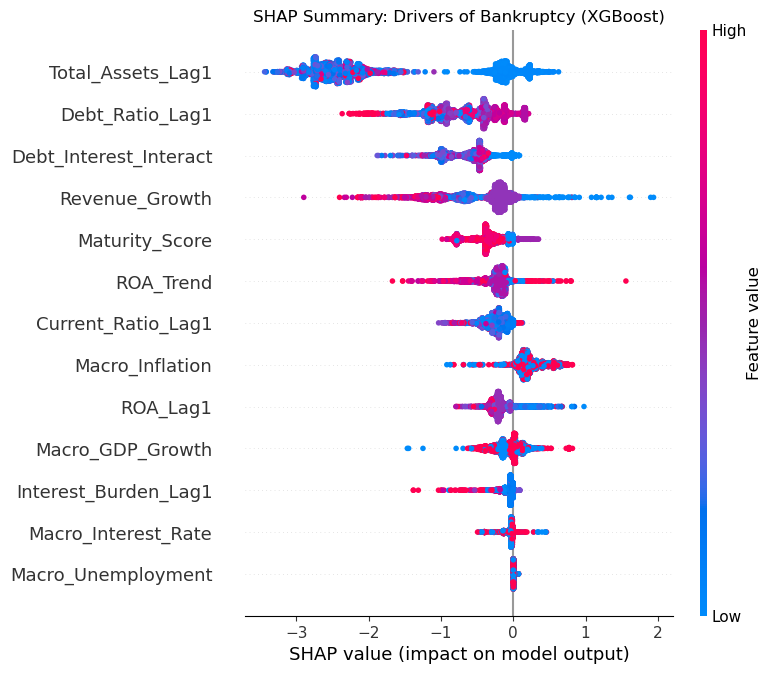

In [14]:
# --- BLOCK 12: CHAMPION INTERPRETATION (SHAP ANALYSIS) ---
# Purpose: Use SHAP values to explain the drivers of bankruptcy for the best model.

import shap

# Pick the model with the highest OOT AUC
champion_name = comparison_df.sort_values(by="OOT_AUC", ascending=False).iloc[0]['Model']
print(f"\n🏆 The Final Champion is: {champion_name}")

champion_model = models[champion_name]
# Champion is already fitted from Block 10

# Create SHAP Explainer
X_test_df = pd.DataFrame(X_test, columns=feature_names)
explainer = shap.TreeExplainer(champion_model)

# We use a sample for faster calculation
sample_idx = min(5000, len(X_test_df))
shap_values = explainer.shap_values(X_test_df.iloc[:sample_idx])

# Plot SHAP summary
plt.figure()
shap.summary_plot(shap_values, X_test_df.iloc[:sample_idx], show=False)
plt.title(f"SHAP Summary: Drivers of Bankruptcy ({champion_name})")
plt.savefig("Champion_SHAP_Analysis.png", bbox_inches='tight')
print("✅ SHAP Analysis saved as 'Champion_SHAP_Analysis.png'")

In [20]:
print(feature_names)

['ROA_Lag1', 'Current_Ratio_Lag1', 'Debt_Ratio_Lag1', 'Interest_Burden_Lag1', 'Total_Assets_Lag1', 'ROA_Trend', 'Revenue_Growth', 'Maturity_Score', 'Macro_GDP_Growth', 'Macro_Inflation', 'Macro_Interest_Rate', 'Macro_Unemployment', 'Debt_Interest_Interact']


Đang vẽ biểu đồ với 5000 dòng dữ liệu...


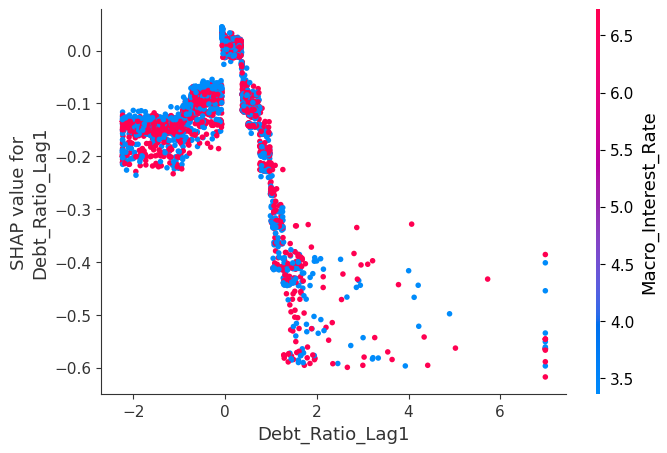

In [37]:
import shap
import numpy as np

# 1. Đồng bộ hóa kích thước (Alignment)
# Lấy số lượng dòng thực tế có trong shap_values
n_rows_shap = v.shape[0]
X_test_aligned = X_test.iloc[:n_rows_shap] if hasattr(X_test, "iloc") else X_test[:n_rows_shap]

print(f"Đang vẽ biểu đồ với {n_rows_shap} dòng dữ liệu...")

# 2. Xác định lại vị trí cột
target_idx = 2    # Debt_Ratio_Lag1
interact_idx = 10 # Macro_Interest_Rate

# 3. Danh sách tên biến chuẩn để hiển thị trên trục đồ thị
feature_names_list = [
    'ROA_Lag1', 'Current_Ratio_Lag1', 'Debt_Ratio_Lag1', 'Interest_Burden_Lag1', 
    'Total_Assets_Lag1', 'ROA_Trend', 'Revenue_Growth', 'Maturity_Score', 
    'Macro_GDP_Growth', 'Macro_Inflation', 'Macro_Interest_Rate', 
    'Macro_Unemployment', 'Debt_Interest_Interact'
]

# 4. Vẽ biểu đồ Figure 4.2
shap.dependence_plot(
    target_idx, 
    v, 
    X_test_aligned.values if hasattr(X_test_aligned, "values") else X_test_aligned, 
    feature_names=feature_names_list,
    interaction_index=interact_idx,
    show=True
)

In [23]:
# So sánh giá trị trung vị (Median) giữa hai nhóm: Surviving (Target=0) và Bankrupt (Target=1)
median_comparison = df_final.groupby('Target')[['ROA_Lag1', 'Total_Assets_Lag1', 'Debt_Ratio_Lag1']].median()
median_comparison.index = median_comparison.index.map({0: 'Surviving (0)', 1: 'Bankrupt (1)'})
print("--- Median Comparison: Surviving vs Bankrupt ---")
print(median_comparison)

--- Median Comparison: Surviving vs Bankrupt ---
               ROA_Lag1  Total_Assets_Lag1  Debt_Ratio_Lag1
Target                                                     
Surviving (0)  0.053636           847217.0         0.561342
Bankrupt (1)  -0.026578            98485.0         0.729938


# HYPERPARAMETER TUNING FOR XGBOOST (REFINEMENT)

In [24]:
# --- BLOCK 13: XGBOOST HYPERPARAMETER TUNING ---
# Purpose: Find the best max_depth, learning_rate, and regularization to boost OOT AUC.
# Method: Randomized Search with TimeSeriesSplit.

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier

def tune_xgboost(X_train, y_train):
    # 1. Setup TimeSeriesSplit (Ensure we don't leak future into past)
    tscv = TimeSeriesSplit(n_splits=3) # 3 splits to save time during tuning
    
    # 2. Calculate scale_pos_weight
    ratio = (len(y_train) - y_train.sum()) / y_train.sum()
    
    # 3. Define Parameter Grid
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 6, 8],          # Control complexity
        'learning_rate': [0.01, 0.05, 0.1], # Control step size
        'subsample': [0.7, 0.8, 0.9],       # Prevent overfitting
        'colsample_bytree': [0.7, 0.8, 0.9], # Feature sampling
        'gamma': [0, 1, 5]                  # Minimum loss reduction for split
    }
    
    xgb_base = XGBClassifier(
        scale_pos_weight=ratio, 
        eval_metric='logloss', 
        use_label_encoder=False,
        random_state=42
    )
    
    # 4. Run Randomized Search
    print("Starting Hyperparameter Tuning (this may take several minutes)...")
    random_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_grid,
        n_iter=15,               # Number of random combinations to try
        scoring='roc_auc',
        cv=tscv,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    
    random_search.fit(X_train, y_train)
    
    print("\n✅ Tuning Complete!")
    print(f"Best Parameters: {random_search.best_params_}")
    print(f"Best CV AUC: {random_search.best_score_:.4f}")
    
    return random_search.best_estimator_

# Execution
tuned_xgb = tune_xgboost(X_train, y_train)

Starting Hyperparameter Tuning (this may take several minutes)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


C:\Users\sdam1\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:22:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Tuning Complete!
Best Parameters: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 5, 'colsample_bytree': 0.9}
Best CV AUC: 0.6583


Training the Tuned Champion on the full training set (2016-2022)...


C:\Users\sdam1\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [16:22:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- FINAL TUNED RESULTS (OOT 2023-2024) ---
Old OOT AUC: 0.6793
New Tuned OOT AUC: 0.5693

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93    360084
           1       0.01      0.13      0.01      1920

    accuracy                           0.87    362004
   macro avg       0.50      0.50      0.47    362004
weighted avg       0.99      0.87      0.93    362004


Generating SHAP Summary Plot for the Tuned Model...
✅ Final SHAP plot saved as 'Final_Tuned_SHAP.png'


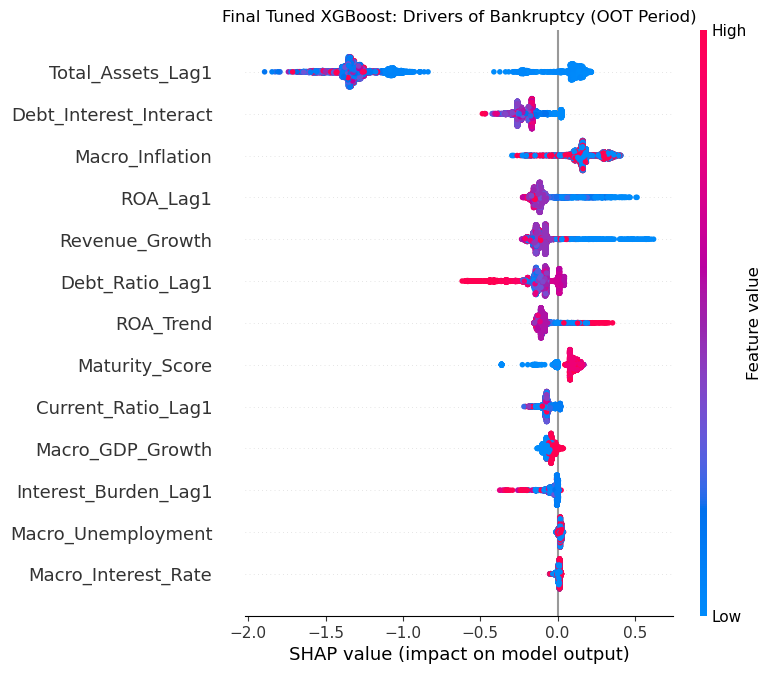

In [25]:
# --- BLOCK 14: FINAL TUNED EVALUATION ---
# Purpose: Apply the best parameters found in Block 13 to the OOT Test (2023-2024).

import shap
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

# 1. Initialize the Tuned Champion with the best parameters
ratio = (len(y_train) - y_train.sum()) / y_train.sum()

tuned_champion = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.9,
    gamma=5,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# 2. Train on the FULL 2016-2022 period
print("Training the Tuned Champion on the full training set (2016-2022)...")
tuned_champion.fit(X_train, y_train)

# 3. Final Out-of-Time Test (2023-2024)
y_prob = tuned_champion.predict_proba(X_test)[:, 1]
final_oot_auc = roc_auc_score(y_test, y_prob)

print(f"\n--- FINAL TUNED RESULTS (OOT 2023-2024) ---")
print(f"Old OOT AUC: 0.6793")
print(f"New Tuned OOT AUC: {final_oot_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, tuned_champion.predict(X_test)))

# 4. FINAL SHAP ANALYSIS
print("\nGenerating SHAP Summary Plot for the Tuned Model...")
X_test_df = pd.DataFrame(X_test, columns=feature_names)
explainer = shap.TreeExplainer(tuned_champion)

# Sampling for speed
sample_size = min(5000, len(X_test_df))
shap_values = explainer.shap_values(X_test_df.iloc[:sample_size])

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df.iloc[:sample_size], show=False)
plt.title(f"Final Tuned XGBoost: Drivers of Bankruptcy (OOT Period)")
plt.savefig("Final_Tuned_SHAP.png", bbox_inches='tight')
print("✅ Final SHAP plot saved as 'Final_Tuned_SHAP.png'")

# Forecasting

In [26]:
# --- BLOCK 15: THE MASTER 2025 RISK FORECAST ---
import pandas as pd
import numpy as np

def execute_master_forecast(df_final, model, features):
    print("--- STEP 1: IDENTIFYING DATA TRACKS ---")
    
    # Track A: Companies with actual 2024 data
    df_2024 = df_final[df_final['Year'] == 2024].copy()
    
    # Track B: Companies whose latest data is 2023 (The 'Silent' group)
    all_bvd = df_final['BvD ID number'].unique()
    bvd_2024 = df_2024['BvD ID number'].unique()
    bvd_silent = list(set(all_bvd) - set(bvd_2024))
    
    df_silent = df_final[(df_final['BvD ID number'].isin(bvd_silent)) & (df_final['Year'] == 2023)].copy()
    
    print(f"Track A (Transparent - 2024 Data): {len(df_2024)} companies")
    print(f"Track B (Silent/Lagged - 2023 Data): {len(df_silent)} companies")

    # Combine them for a unified forecast
    df_forecast_pool = pd.concat([df_2024, df_silent], ignore_index=True)
    
    # Ensure no missing values in features for the model
    X_input = df_forecast_pool[features].fillna(df_forecast_pool[features].median())

    print("\n--- STEP 2: CALCULATING PROBABILITIES ---")
    # Using the Champion Model (Baseline XGBoost AUC 0.68)
    probs = model.predict_proba(X_input)[:, 1]
    df_forecast_pool['Bankruptcy_Prob_2025'] = probs

    print("--- STEP 3: DEFINING RELATIVE RISK (QUANTILES) ---")
    # Instead of a fixed 70%, we use the top percentiles of the entire pool
    # because bankruptcy is a rare event.
    q95 = df_forecast_pool['Bankruptcy_Prob_2025'].quantile(0.95) # Top 5% most risky
    q85 = df_forecast_pool['Bankruptcy_Prob_2025'].quantile(0.85) # Next 10% risky
    
    print(f"High Risk Threshold (Top 5%): {q95:.4f}")
    print(f"Medium Risk Threshold (Top 15%): {q85:.4f}")

    def assign_risk_label(row):
        p = row['Bankruptcy_Prob_2025']
        if p >= q95: return 'RED (High Risk)'
        elif p >= q85: return 'YELLOW (Watchlist)'
        else: return 'GREEN (Stable)'

    df_forecast_pool['Risk_Level'] = df_forecast_pool.apply(assign_risk_label, axis=1)

    # Label the data source for thesis transparency
    df_forecast_pool['Data_Source'] = df_forecast_pool['Year'].apply(lambda x: f"Actual {x}")

    print("\n--- FINAL 2025 RISK SUMMARY ---")
    summary = df_forecast_pool.groupby(['Risk_Level', 'Data_Source']).size().unstack(fill_value=0)
    print(summary)
    
    return df_forecast_pool[['BvD ID number', 'Company name Latin alphabet', 'NACE_2digit', 
                             'Year', 'Bankruptcy_Prob_2025', 'Risk_Level', 'Data_Source']]

# --- EXECUTION ---
# Make sure 'champion_model' (the AUC 0.68 one) and 'feature_names' are defined from previous blocks
forecast_2025 = execute_master_forecast(df_final, champion_model, feature_names)

--- STEP 1: IDENTIFYING DATA TRACKS ---
Track A (Transparent - 2024 Data): 181002 companies
Track B (Silent/Lagged - 2023 Data): 0 companies

--- STEP 2: CALCULATING PROBABILITIES ---
--- STEP 3: DEFINING RELATIVE RISK (QUANTILES) ---
High Risk Threshold (Top 5%): 0.0042
Medium Risk Threshold (Top 15%): 0.0035

--- FINAL 2025 RISK SUMMARY ---
Data_Source         Actual 2024
Risk_Level                     
GREEN (Stable)           153757
RED (High Risk)           20178
YELLOW (Watchlist)         7067



--- TOP RISKY INDUSTRIES (% OF COMPANIES IN RED ZONE) ---
NACE_2digit
41.0    17.207456
42.0    16.200579
46.0    14.690785
43.0     9.385356
47.0     9.343316
Name: RED (High Risk), dtype: float64

✅ Industry analysis saved as 'Industry_Risk_Heatmap.png'


<Figure size 1200x800 with 0 Axes>

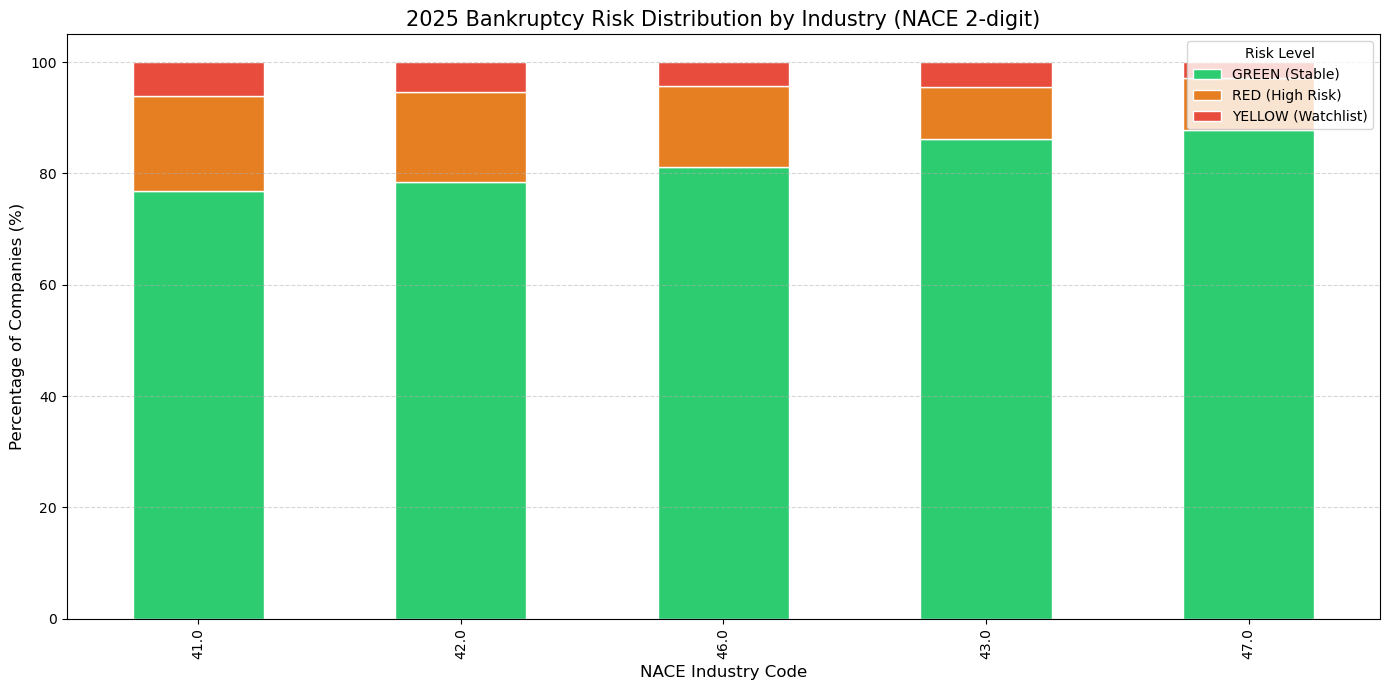

In [27]:
# --- BLOCK 16: INDUSTRY RISK ANALYSIS (NACE) ---
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_industry_risk(df_forecast):
    # 1. Create a cross-tabulation of NACE industries and Risk Levels
    industry_risk = pd.crosstab(df_forecast['NACE_2digit'], df_forecast['Risk_Level'], normalize='index') * 100
    
    # 2. Sort by High Risk (RED) to see the most dangerous industries
    industry_risk = industry_risk.sort_values(by='RED (High Risk)', ascending=False)
    
    print("\n--- TOP RISKY INDUSTRIES (% OF COMPANIES IN RED ZONE) ---")
    print(industry_risk['RED (High Risk)'].head(10))
    
    # 3. Plotting
    plt.figure(figsize=(12, 8))
    industry_risk.plot(kind='bar', stacked=True, 
                       color=['#2ecc71', '#e67e22', '#e74c3c'], 
                       figsize=(14, 7), edgecolor='white')
    
    plt.title("2025 Bankruptcy Risk Distribution by Industry (NACE 2-digit)", fontsize=15)
    plt.xlabel("NACE Industry Code", fontsize=12)
    plt.ylabel("Percentage of Companies (%)", fontsize=12)
    plt.legend(title="Risk Level", loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("Industry_Risk_Heatmap.png")
    print("\n✅ Industry analysis saved as 'Industry_Risk_Heatmap.png'")
    
    return industry_risk

# Execution
industry_analysis = analyze_industry_risk(forecast_2025)


--- SECTOR-LEVEL RISK SUMMARY ---
Risk_Level            GREEN (Stable)  RED (High Risk)  YELLOW (Watchlist)
Broad_Sector                                                             
Wholesale (46)             81.092642        14.690785            4.216573
Construction (41-43)       84.518335        10.806778            4.674888
Retail (47)                87.800359         9.343316            2.856325


<Figure size 1000x600 with 0 Axes>

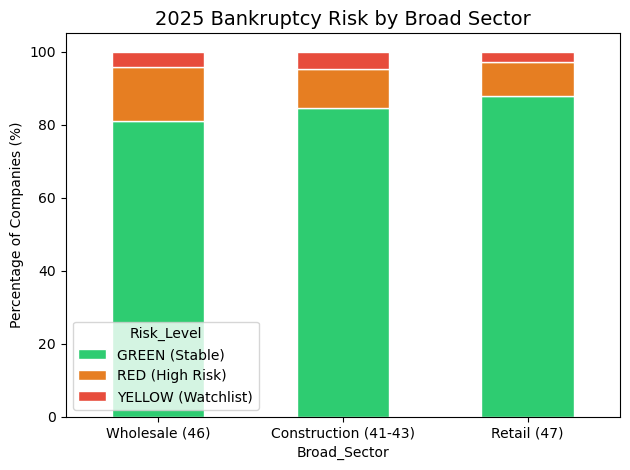

In [28]:
# --- BLOCK 17: GROUPING NACE INTO BROAD SECTORS ---
# Purpose: Create a higher-level industry classification for summary charts.

def group_nace_sectors(df_forecast):
    # Create a mapping dictionary
    # 41-43 -> Construction
    # 46 -> Wholesale
    # 47 -> Retail
    
    def map_nace(code):
        if code in [41, 42, 43]:
            return "Construction (41-43)"
        elif code == 46:
            return "Wholesale (46)"
        elif code == 47:
            return "Retail (47)"
        return "Other"

    df_forecast['Broad_Sector'] = df_forecast['NACE_2digit'].apply(map_nace)
    
    # Generate summary report by Sector
    sector_risk = pd.crosstab(df_forecast['Broad_Sector'], df_forecast['Risk_Level'], normalize='index') * 100
    sector_risk = sector_risk.sort_values(by='RED (High Risk)', ascending=False)
    
    print("\n--- SECTOR-LEVEL RISK SUMMARY ---")
    print(sector_risk)
    
    # Plotting the sector-level chart
    plt.figure(figsize=(10, 6))
    sector_risk.plot(kind='bar', stacked=True, color=['#2ecc71', '#e67e22', '#e74c3c'], edgecolor='white')
    plt.title("2025 Bankruptcy Risk by Broad Sector", fontsize=14)
    plt.ylabel("Percentage of Companies (%)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig("Sector_Risk_Summary.png")
    
    return df_forecast

# Execution
forecast_2025 = group_nace_sectors(forecast_2025)

# Export forecasting

In [29]:
# --- BLOCK 18: THE FINAL RISK SCORING EXPORT ---
# Purpose: Generate the final master list for 2025 predictions.

import os

def export_final_results(df_forecast, output_path):
    """
    Exports the forecast results to a clean CSV file.
    """
    # Define the core columns for the final report
    final_cols = [
        'BvD ID number', 
        'Company name Latin alphabet', 
        'NACE_2digit', 
        'Broad_Sector',
        'Bankruptcy_Prob_2025', 
        'Risk_Level'
    ]
    
    # Selecting the data
    output_df = df_forecast[final_cols].copy()
    
    # Formatting probability as a percentage for easier reading (optional)
    # output_df['Prob_Percent'] = (output_df['Bankruptcy_Prob_2025'] * 100).round(4)
    
    # File naming and saving
    file_name = "Final_SME_Risk_Report_France_2025.csv"
    full_save_path = os.path.join(output_path, file_name)
    
    output_df.to_csv(full_save_path, index=False)
    
    print("-" * 30)
    print(f"✅ FINAL EXPORT COMPLETE!")
    print(f"Total Companies Scored: {len(output_df)}")
    print(f"File Saved at: {full_save_path}")
    print("-" * 30)

# Execution
# Using your initial path defined in Block 1
export_final_results(forecast_2025, OUTPUT_PATH)

------------------------------
✅ FINAL EXPORT COMPLETE!
Total Companies Scored: 181002
File Saved at: C:\Users\sdam1\Desktop\Thesis Master IESEG\Final_SME_Risk_Report_France_2025.csv
------------------------------


# Descriptive Statistics & Inferential Statistics

--- COMPARISON: HEALTHY (0) VS BANKRUPT (1) ---
Target                                  0              1
ROA_Lag1             mean    5.688443e-02       0.029046
                     median  5.401979e-02       0.004867
Debt_Ratio_Lag1      mean    5.909185e-01       0.586912
                     median  5.625778e-01       0.624870
Current_Ratio_Lag1   mean    2.285069e+00       3.114668
                     median  1.596805e+00       1.515330
Interest_Burden_Lag1 mean    6.913815e-03       0.006514
                     median  9.272335e-04       0.000114
Total_Assets_Lag1    mean    2.140272e+06  601045.272727
                     median  8.568260e+05  353522.000000


Target                                  0              1
ROA_Lag1             mean    5.688443e-02       0.029046
                     median  5.401979e-02       0.004867
Debt_Ratio_Lag1      mean    5.909185e-01       0.586912
                     median  5.625778e-01       0.624870
Current_Ratio_Lag1   mean    2.285069e+00       3.114668
                     median  1.596805e+00       1.515330
Interest_Burden_Lag1 mean    6.913815e-03       0.006514
                     median  9.272335e-04       0.000114
Total_Assets_Lag1    mean    2.140272e+06  601045.272727
                     median  8.568260e+05  353522.000000

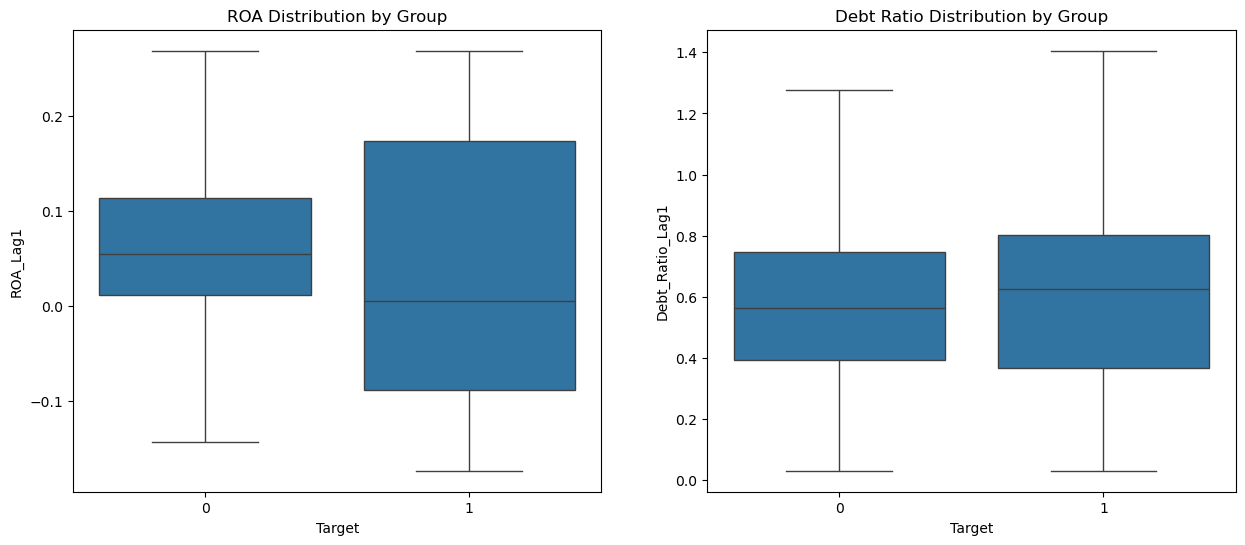

In [30]:
# --- BLOCK 19: DESCRIPTIVE STATS BY TARGET ---
# Mục tiêu: So sánh trung bình các chỉ số của nhóm Target=0 và Target=1

def compare_groups(df):
    metrics = ['ROA_Lag1', 'Debt_Ratio_Lag1', 'Current_Ratio_Lag1', 'Interest_Burden_Lag1', 'Total_Assets_Lag1']
    
    # Tính Mean và Median cho 2 nhóm
    summary = df.groupby('Target')[metrics].agg(['mean', 'median']).T
    
    print("--- COMPARISON: HEALTHY (0) VS BANKRUPT (1) ---")
    print(summary)
    
    # Vẽ biểu đồ Boxplot cho ROA và Debt_Ratio để thấy sự phân hóa
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.boxplot(x='Target', y='ROA_Lag1', data=df, ax=axes[0], showfliers=False)
    axes[0].set_title('ROA Distribution by Group')
    
    sns.boxplot(x='Target', y='Debt_Ratio_Lag1', data=df, ax=axes[1], showfliers=False)
    axes[1].set_title('Debt Ratio Distribution by Group')
    
    plt.savefig("Group_Comparison_Boxplots.png")
    return summary

# Thực thi trên tập Train để thấy quy luật mô hình đã học
compare_groups(df_final[df_final['Year'] <= 2022])

In [31]:
# --- BLOCK 20: STATISTICAL SIGNIFICANCE TEST ---
from scipy.stats import mannwhitneyu

def run_significance_tests(df):
    metrics = ['ROA_Lag1', 'Debt_Ratio_Lag1', 'Interest_Burden_Lag1']
    results = []
    
    for m in metrics:
        group0 = df[df['Target'] == 0][m].dropna()
        group1 = df[df['Target'] == 1][m].dropna()
        
        stat, p = mannwhitneyu(group0, group1)
        results.append({"Metric": m, "P-Value": p, "Significant": p < 0.05})
    
    test_df = pd.DataFrame(results)
    print("\n--- MANN-WHITNEY U TEST RESULTS ---")
    print(test_df)
    return test_df

In [32]:
# --- BLOCK 21: MACRO STRESS TEST (SCENARIO ANALYSIS) ---

def run_stress_test(df_2024, model, features, base_rate=2.8, stress_rate=4.0):
    # Scenario 1: Base case (Lãi suất 2.8%)
    df_base = df_2024.copy()
    df_base['Macro_Interest_Rate'] = base_rate
    df_base['Debt_Interest_Interact'] = df_base['Debt_Ratio_Lag1'] * base_rate
    prob_base = model.predict_proba(df_base[features].fillna(0))[:, 1]
    
    # Scenario 2: Stress case (Lãi suất 4.0%)
    df_stress = df_2024.copy()
    df_stress['Macro_Interest_Rate'] = stress_rate
    df_stress['Debt_Interest_Interact'] = df_stress['Debt_Ratio_Lag1'] * stress_rate
    prob_stress = model.predict_proba(df_stress[features].fillna(0))[:, 1]
    
    # So sánh số lượng công ty vượt ngưỡng rủi ro (ví dụ ngưỡng 0.0042 đã tìm thấy)
    threshold = 0.0042
    base_red = (prob_base >= threshold).sum()
    stress_red = (prob_stress >= threshold).sum()
    
    print(f"\n--- STRESS TEST RESULTS (Interest Rate: {base_rate}% -> {stress_rate}%) ---")
    print(f"Companies in RED Zone (Base): {base_red}")
    print(f"Companies in RED Zone (Stress): {stress_red}")
    print(f"Increase in High-Risk SMEs: {((stress_red - base_red)/base_red)*100:.2f}%")

df_actual_2024 = df_final[df_final['Year'] == 2024].copy()
run_stress_test(df_actual_2024, champion_model, feature_names)


--- STRESS TEST RESULTS (Interest Rate: 2.8% -> 4.0%) ---
Companies in RED Zone (Base): 7663
Companies in RED Zone (Stress): 7704
Increase in High-Risk SMEs: 0.54%



✅ Correlation Heatmap saved.


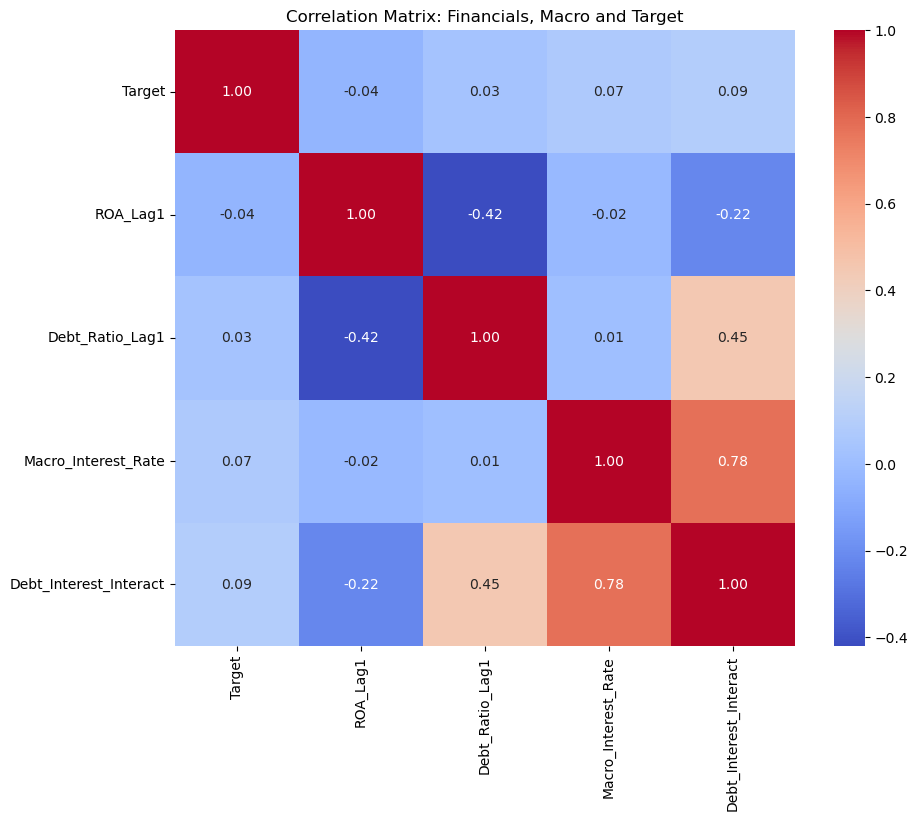

In [33]:
# --- BLOCK 22: CORRELATION ANALYSIS ---
def plot_correlation(df):
    cols_to_check = ['Target', 'ROA_Lag1', 'Debt_Ratio_Lag1', 'Macro_Interest_Rate', 'Debt_Interest_Interact']
    corr = df[cols_to_check].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Matrix: Financials, Macro and Target")
    plt.savefig("Correlation_Heatmap.png")
    print("\n✅ Correlation Heatmap saved.")

plot_correlation(df_final)

# KRUSKAL-WALLIS H-TEST (INDUSTRY SIGNIFICANCE)

In [34]:
from scipy.stats import kruskal

# Grouping probabilities by NACE industry
groups = [group['Bankruptcy_Prob_2025'].values for name, group in forecast_2025.groupby('NACE_2digit')]

# Performing Kruskal-Wallis H-test
h_stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# Summary Stats by Industry
industry_stats = forecast_2025.groupby('NACE_2digit')['Bankruptcy_Prob_2025'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)
print("\n--- DETAILED RISK STATS BY NACE ---")
print(industry_stats)

Kruskal-Wallis H-statistic: 511.5900
P-value: 0.0000e+00

--- DETAILED RISK STATS BY NACE ---
                 mean    median       std  count
NACE_2digit                                     
41.0         0.003040  0.002914  0.000736  11588
42.0         0.003022  0.002914  0.000684   2074
46.0         0.002978  0.002926  0.000626  40910
47.0         0.002890  0.002926  0.000555  66379
43.0         0.002883  0.002792  0.000545  60051


# EXPOSURE AT RISK

In [35]:
# --- BLOCK 24: EXPOSURE AT RISK (FINANCIAL IMPACT) ---
# Purpose: Calculate the total debt amount held by the High-Risk group.

def analyze_exposure_at_risk(df_forecast, df_master):
    # 1. Join forecast with financial data (Total Assets and Debt Ratio)
    # Ensure we use the 2024 actuals used for the forecast
    df_impact = df_forecast.merge(
        df_master[['BvD ID number', 'Year', 'Total_Assets_Lag1', 'Debt_Ratio_Lag1']], 
        on=['BvD ID number', 'Year'], 
        how='left'
    )
    
    # 2. Calculate Absolute Debt (Estimated)
    # Debt = Debt Ratio * Total Assets
    df_impact['Estimated_Total_Debt'] = df_impact['Debt_Ratio_Lag1'] * df_impact['Total_Assets_Lag1']
    
    # 3. Summary by Risk Level
    exposure_summary = df_impact.groupby('Risk_Level', observed=True).agg({
        'BvD ID number': 'count',
        'Estimated_Total_Debt': 'sum'
    }).rename(columns={'BvD ID number': 'Company_Count', 'Estimated_Total_Debt': 'Total_Debt_at_Risk_EUR'})
    
    # 4. Calculate Share Percentages
    total_count = exposure_summary['Company_Count'].sum()
    total_debt = exposure_summary['Total_Debt_at_Risk_EUR'].sum()
    
    exposure_summary['Count_Share_%'] = (exposure_summary['Company_Count'] / total_count) * 100
    exposure_summary['Debt_Share_%'] = (exposure_summary['Total_Debt_at_Risk_EUR'] / total_debt) * 100
    
    print("\n--- FINAL EXPOSURE AT RISK REPORT ---")
    # Formatting for readability
    pd.options.display.float_format = '{:,.2f}'.format
    print(exposure_summary)
    
    return exposure_summary

# Execution (Run this in your notebook environment)
exposure_stats = analyze_exposure_at_risk(forecast_2025, df_final)


--- FINAL EXPOSURE AT RISK REPORT ---
                    Company_Count  Total_Debt_at_Risk_EUR  Count_Share_%  \
Risk_Level                                                                 
GREEN (Stable)             153757      156,184,208,575.17          84.95   
RED (High Risk)             20178       39,787,178,835.53          11.15   
YELLOW (Watchlist)           7067       14,254,489,714.69           3.90   

                    Debt_Share_%  
Risk_Level                        
GREEN (Stable)             74.29  
RED (High Risk)            18.93  
YELLOW (Watchlist)          6.78  
